# Foro Clase 5 - Aprendizaje Automático

## Predicción de diabetes con K-NN y Árbol de Decisión

En este trabajo se utilizará un dataset de Kaggle sobre predicción de diabetes. El objetivo es aplicar dos modelos de aprendizaje automático supervisado: K-Nearest Neighbors (K-NN) y Árbol de Decisión, para comparar su desempeño en una tarea de clasificación.

In [2]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset
df = pd.read_csv('/diabetes_prediction_dataset.csv')

# Mostrar primeras filas
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [4]:
# Estadísticas generales
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [5]:
# Ver valores únicos de las variables categóricas

print(df['gender'].unique())
print(df['smoking_history'].unique())

['Female' 'Male' 'Other']
['never' 'No Info' 'current' 'former' 'ever' 'not current']


In [6]:
# Convertir variables categóricas a numéricas

df['gender'] = df['gender'].map({
    'Female': 0,
    'Male': 1,
    'Other': 2
})

df['smoking_history'] = df['smoking_history'].map({
    'never': 0,
    'No Info': 1,
    'current': 2,
    'former': 3,
    'ever': 4,
    'not current': 5
})

# Verificar cambios
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,0,25.19,6.6,140,0
1,0,54.0,0,0,1,27.32,6.6,80,0
2,1,28.0,0,0,0,27.32,5.7,158,0
3,0,36.0,0,0,2,23.45,5.0,155,0
4,1,76.0,1,1,2,20.14,4.8,155,0


In [7]:
# Definición de variables

X = df.drop('diabetes', axis=1)
y = df['diabetes']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Descripción de las variables

## Variables utilizadas en el dataset

- gender: género de la persona.
- age: edad.
- hypertension: indica si la persona tiene hipertensión (0 = no, 1 = sí).
- heart_disease: indica presencia de enfermedad cardíaca.
- smoking_history: historial de tabaquismo.
- bmi: índice de masa corporal.
- HbA1c_level: nivel de hemoglobina glucosilada.
- blood_glucose_level: nivel de glucosa en sangre.
- diabetes: variable objetivo del modelo (0 = no diabetes, 1 = diabetes).

# Modelo K-NN

Se aplica el algoritmo K-Nearest Neighbors para clasificar si una persona presenta diabetes o no. Este modelo clasifica según la cercanía entre los datos, utilizando los vecinos más próximos.

In [15]:
# Modelo KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [12]:
# Seleccionamos dos variables para visualización

X_vis = df[['blood_glucose_level', 'HbA1c_level']].values
y_vis = df['diabetes'].values

In [13]:
from sklearn.preprocessing import StandardScaler

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y_vis,
    test_size=0.3,
    random_state=42
)

scaler = StandardScaler()

X_train_vis_sc = scaler.fit_transform(X_train_vis)
X_test_vis_sc = scaler.transform(X_test_vis)

In [14]:
# Modelo KNN para visualización

knn_vis = KNeighborsClassifier(n_neighbors=5)

knn_vis.fit(X_train_vis_sc, y_train_vis)

KNeighborsClassifier()

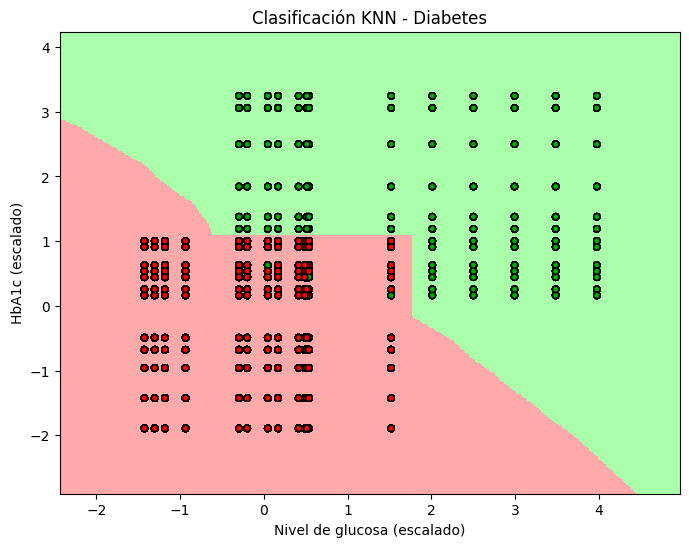

In [16]:
from matplotlib.colors import ListedColormap

h = 0.02

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
cmap_bold = ListedColormap(['#FF0000', '#00AA00'])

x_min, x_max = X_train_vis_sc[:, 0].min() - 1, X_train_vis_sc[:, 0].max() + 1
y_min, y_max = X_train_vis_sc[:, 1].min() - 1, X_train_vis_sc[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')

plt.scatter(
    X_train_vis_sc[:, 0],
    X_train_vis_sc[:, 1],
    c=y_train_vis,
    cmap=cmap_bold,
    edgecolor='k',
    s=20
)

plt.xlabel('Nivel de glucosa (escalado)')
plt.ylabel('HbA1c (escalado)')

plt.title('Clasificación KNN - Diabetes')

plt.show()

# 9. Evaluación del modelo K-NN

Se evalúa el rendimiento del modelo K-NN utilizando métricas de clasificación y matriz de confusión.

In [17]:
# Accuracy y reporte de clasificación KNN

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("Accuracy del modelo KNN:", accuracy_knn)

print("\nReporte de clasificación KNN:")
print(classification_report(y_test, y_pred_knn))

Accuracy del modelo KNN: 0.9516

Reporte de clasificación KNN:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     27453
           1       0.87      0.50      0.64      2547

    accuracy                           0.95     30000
   macro avg       0.92      0.75      0.81     30000
weighted avg       0.95      0.95      0.95     30000



# Árbol de Decisión

El Árbol de Decisión permite clasificar pacientes mediante reglas basadas en las variables del dataset.

Este modelo divide los datos en diferentes ramas hasta llegar a una predicción final, facilitando la interpretación de los resultados.

In [19]:
# Modelo Árbol de Decisión

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Accuracy Árbol:", accuracy_score(y_test, y_pred_tree))

print("\nReporte de clasificación Árbol:\n")
print(classification_report(y_test, y_pred_tree))

Accuracy Árbol: 0.9715666666666667

Reporte de clasificación Árbol:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27453
           1       1.00      0.67      0.80      2547

    accuracy                           0.97     30000
   macro avg       0.98      0.83      0.89     30000
weighted avg       0.97      0.97      0.97     30000



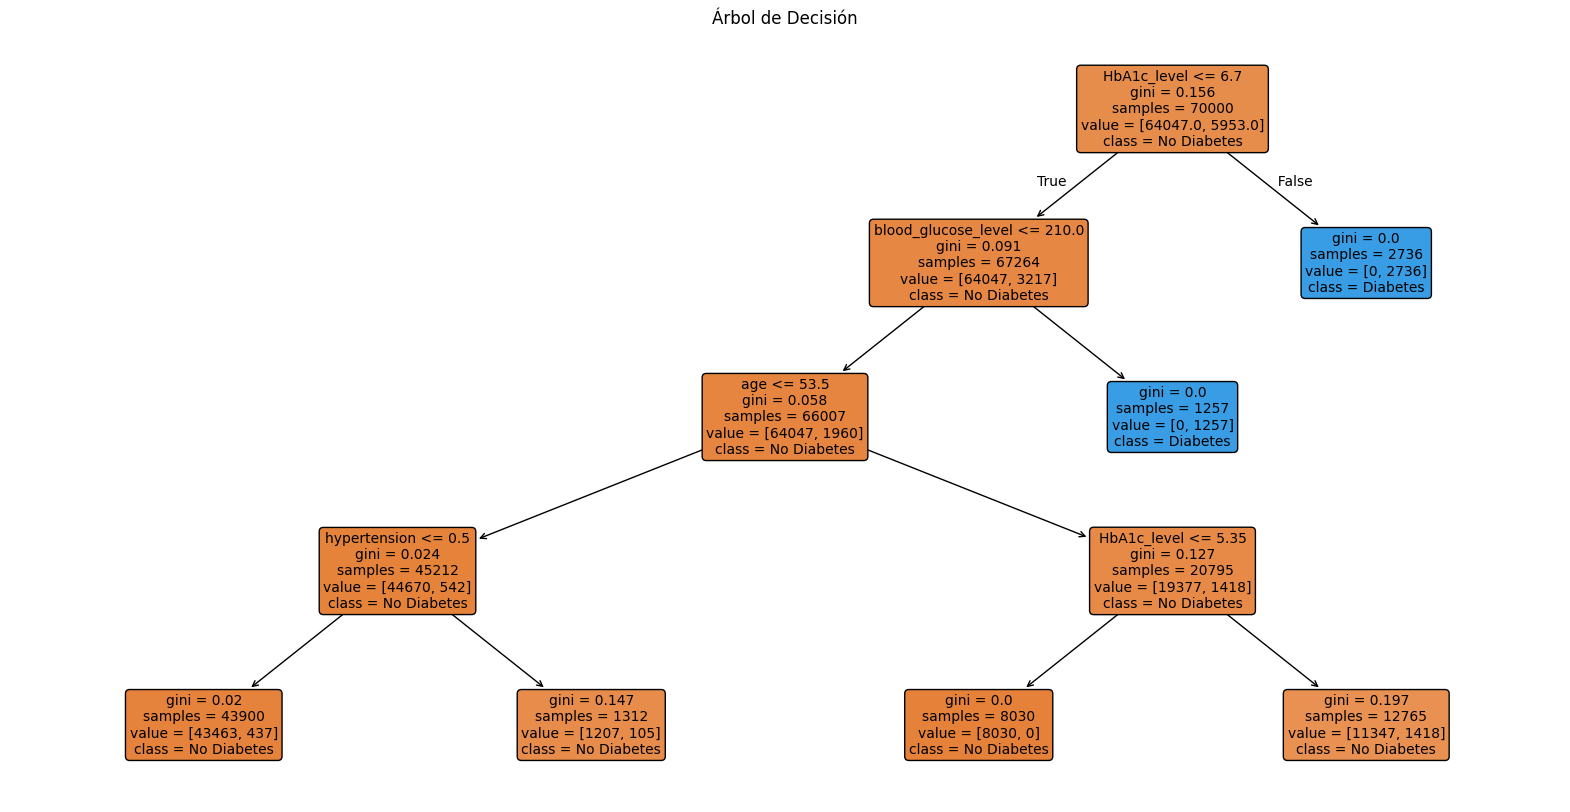

In [20]:
# Visualización del Árbol de Decisión

from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árbol de Decisión")
plt.show()

# Comparación de modelos

A continuación se comparan las matrices de confusión de K-NN y Árbol de Decisión para analizar el desempeño de ambos modelos en la clasificación de pacientes con diabetes.

Accuracy KNN: 0.9516
Accuracy Árbol: 0.9715666666666667


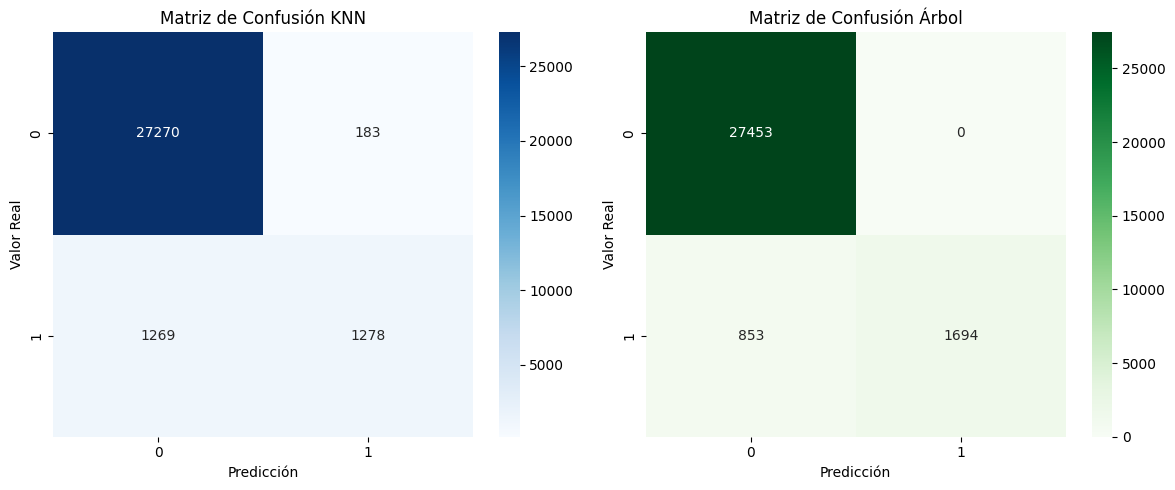

In [21]:
# Comparación de matrices de confusión

print("Accuracy KNN:", accuracy_knn)
print("Accuracy Árbol:", accuracy_score(y_test, y_pred_tree))

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Matriz KNN
sns.heatmap(
    confusion_matrix(y_test, y_pred_knn),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0]
)

ax[0].set_title("Matriz de Confusión KNN")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor Real")

# Matriz Árbol
sns.heatmap(
    confusion_matrix(y_test, y_pred_tree),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=ax[1]
)

ax[1].set_title("Matriz de Confusión Árbol")
ax[1].set_xlabel("Predicción")
ax[1].set_ylabel("Valor Real")

plt.tight_layout()
plt.show()

## Conclusión

En este trabajo se aplicaron dos algoritmos de aprendizaje supervisado, K-Nearest Neighbors (KNN) y Árbol de Decisión, con el objetivo de clasificar pacientes según la presencia o no de diabetes utilizando un dataset obtenido de Kaggle.

Como primera etapa se realizó la exploración y preparación de los datos. Se analizaron las variables del dataset, se verificaron sus tipos de datos y se transformaron las variables categóricas (`gender` y `smoking_history`) a valores numéricos para permitir el entrenamiento de los modelos de machine learning.

Posteriormente se dividieron los datos en conjuntos de entrenamiento y prueba utilizando `train_test_split`, permitiendo evaluar el desempeño de los algoritmos sobre datos no utilizados durante el entrenamiento.

El modelo KNN obtuvo una accuracy aproximada del 95%, mostrando un muy buen rendimiento general. El reporte de clasificación indicó altos valores de precisión y recall para la clase correspondiente a pacientes sin diabetes, aunque presentó una menor capacidad para detectar algunos casos positivos de diabetes. Esto puede deberse al desbalance presente en el dataset, donde existen más registros de pacientes sin diabetes que con diabetes.

Además, mediante la visualización gráfica del modelo KNN se pudo observar cómo el algoritmo clasifica los datos utilizando las variables `blood_glucose_level` y `HbA1c_level`. Las regiones coloreadas representan las zonas donde el modelo predice diabetes o no diabetes según la cercanía entre los puntos. Esta representación permitió comprender visualmente el funcionamiento del algoritmo basado en vecinos más cercanos.

Por otro lado, el modelo de Árbol de Decisión alcanzó una accuracy cercana al 97%, obteniendo un desempeño levemente superior al KNN. El árbol generado permitió interpretar de manera más clara las decisiones tomadas por el modelo, mostrando las condiciones y divisiones realizadas a partir de variables como niveles de glucosa, HbA1c e hipertensión.

Al comparar las matrices de confusión de ambos modelos, se observó que los dos algoritmos clasifican correctamente la mayoría de los casos. Sin embargo, el Árbol de Decisión logró identificar una mayor cantidad de pacientes con diabetes, reduciendo algunos errores de clasificación presentes en KNN.

En conclusión, ambos algoritmos demostraron ser útiles para problemas de clasificación supervisada aplicados a salud. No obstante, el modelo de Árbol de Decisión presentó mejores resultados generales sobre este dataset, además de ofrecer una interpretación más sencilla y visual del proceso de decisión utilizado para clasificar los pacientes.